# Avito OCR orientation — V3 Final

**Цель:** максимизировать `1 - Brier Score` на 20 000 тестовых OCR-crops.

V3 сохраняет рабочую идею V2 (EfficientNet-B0 + PaddleOCR orientation), но меняет схему валидации и ансамблирования:

1. leakage-free group split по исходным crops;
2. 180°-symmetry через разность logits, а не только averaging probabilities;
3. официальный `PP-LCNet_x1_0_textline_ori` как независимый эксперт;
4. опциональный PaddleOCR recognition signal `original vs rot180`;
5. 5-fold OOF для обучения маленькой meta-model;
6. calibration оптимизируется по Brier на OOF;
7. после OOF обучается один финальный EfficientNet на всех train crops;
8. test submission строится теми же признаками и тем же meta-model.

> **Воспроизводимость:** все random seeds фиксированы. Test labels нигде не используются. Unlabeled test используется только для inference, не для обучения.


In [1]:
# ============================================================
# 0. INSTALL + CONFIG
# ============================================================
# Для Colab/Jupyter. PaddleOCR 3.x официально предоставляет
# TextLineOrientationClassification и PP-LCNet_x1_0_textline_ori.
!pip -q install -U pandas numpy "pillow<11.2.0" tqdm scikit-learn matplotlib wordfreq paddleocr


import os, re, io, json, random, math, subprocess, warnings, gc, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance, ImageOps
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm.auto import tqdm

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROOT = Path("/content/avito_orientation_v3")
DATA = ROOT / "data"
CKPT = ROOT / "checkpoints"
CACHE = ROOT / "cache"
for p in [ROOT, DATA, CKPT, CACHE]: p.mkdir(parents=True, exist_ok=True)

CFG = {
    "image_h": 128, "image_w": 256,
    "batch_size": 64 if torch.cuda.is_available() else 16,
    "num_workers": 2,
    "oof_folds": 5,
    "oof_epochs": 4,
    "final_epochs": 6,
    "freeze_epochs": 1,
    "lr_head": 2e-3, "lr_backbone": 2e-4,
    "weight_decay": 1e-4, "dropout": 0.20,
    "synthetic_fraction": 0.55,
    "PADDLE_MODEL": "PP-LCNet_x1_0_textline_ori",
    "USE_PADDLE": True,
    "USE_OCR_RECOGNITION": True,
    "OCR_MODEL": "PP-OCRv5_mobile_rec",
    # If OOF training is too slow for a first dry run, set False.
    # For the final submission keep True.
    "RUN_OOF": True,
}
IMG_EXTS={".jpg",".jpeg",".png",".bmp",".webp"}
print("DEVICE:",DEVICE)
print(json.dumps(CFG,indent=2))


DEVICE: cuda
{
  "image_h": 128,
  "image_w": 256,
  "batch_size": 64,
  "num_workers": 2,
  "oof_folds": 5,
  "oof_epochs": 4,
  "final_epochs": 6,
  "freeze_epochs": 1,
  "lr_head": 0.002,
  "lr_backbone": 0.0002,
  "weight_decay": 0.0001,
  "dropout": 0.2,
  "synthetic_fraction": 0.55,
  "PADDLE_MODEL": "PP-LCNet_x1_0_textline_ori",
  "USE_PADDLE": true,
  "USE_OCR_RECOGNITION": true,
  "OCR_MODEL": "PP-OCRv5_mobile_rec",
  "RUN_OOF": true
}


## 1. IIIT5K: real word crops and group-safe split

Each original crop is one **group**. Its 0° and 180° variants are generated only inside the same split, so no rotated copy can leak between train/validation.


In [5]:
from pathlib import Path
import subprocess
import zipfile

In [6]:
!apt-get update && apt-get install -y git-lfs
!git lfs install

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [359 B]
Get:5 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,877 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:8 http://archive.ubuntu.com/ubuntu noble InRelease
Get:9 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:13 http://security.ubuntu.com/ubuntu noble-secur

In [7]:
!rm -rf /content/extracted_iiit

In [8]:
!rm -rf /content/avito_orientation_v3/data/iiit5k

In [9]:
# ============================================================
# 1. IIIT5K
# ============================================================
IIIT_DIR = DATA / "iiit5k"
if not IIIT_DIR.exists():
    subprocess.run(["git","clone","--depth","1","https://github.com/adumrewal/iiit-5k-word-coco-dataset.git",str(IIIT_DIR)],check=True)
subprocess.run(["git","lfs","pull"],cwd=str(IIIT_DIR),stdout=subprocess.PIPE,stderr=subprocess.STDOUT,check=False)


CompletedProcess(args=['git', 'lfs', 'pull'], returncode=0, stdout=b'')

In [10]:
!unzip "/content/avito_orientation_v3/data/iiit5k/IIIT5K_coco.zip" -d "/content/extracted_iiit"

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/883_7.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/570_3.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/2008_1.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/2078_8.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/1044_7.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/122_5.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/5129_4.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/590_6.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/902_6.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/1082_1.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/218_3.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/labels/test/710_7.txt  
  inflating: /content/extracted_iiit/IIIT5K_coco/la

In [12]:

def find_images(root):
    return sorted([p for p in Path(root).rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])

images=find_images(Path("/content/extracted_iiit/IIIT5K_coco/images"))
if not images: raise RuntimeError("IIIT5K images not found. Check git-lfs.")
rows=[]
for p in tqdm(images,desc="IIIT metadata"):
    try:
        with Image.open(p) as im: w,h=im.size
        r=w/max(h,1)
        bucket="tall" if r<0.75 else "square" if r<1.5 else "wide" if r<3 else "very_wide"
        rows.append((str(p),bucket))
    except Exception: pass
df=pd.DataFrame(rows,columns=["path","bucket"])
train_paths,val_paths=train_test_split(df.path.tolist(),test_size=.20,random_state=SEED,stratify=df.bucket.tolist())
train_paths=list(train_paths); val_paths=list(val_paths)
print("images:",len(df),"train:",len(train_paths),"val:",len(val_paths))

IIIT metadata:   0%|          | 0/5000 [00:00<?, ?it/s]

images: 5000 train: 4000 val: 1000


## 2. Domain-matched synthetic text

Synthetic data is still useful, but V3 makes it less clean: varied fonts, backgrounds, text types, blur, resize, JPEG, noise, contrast/brightness and mild geometric distortion. The purpose is augmentation, not a replacement for real crops.


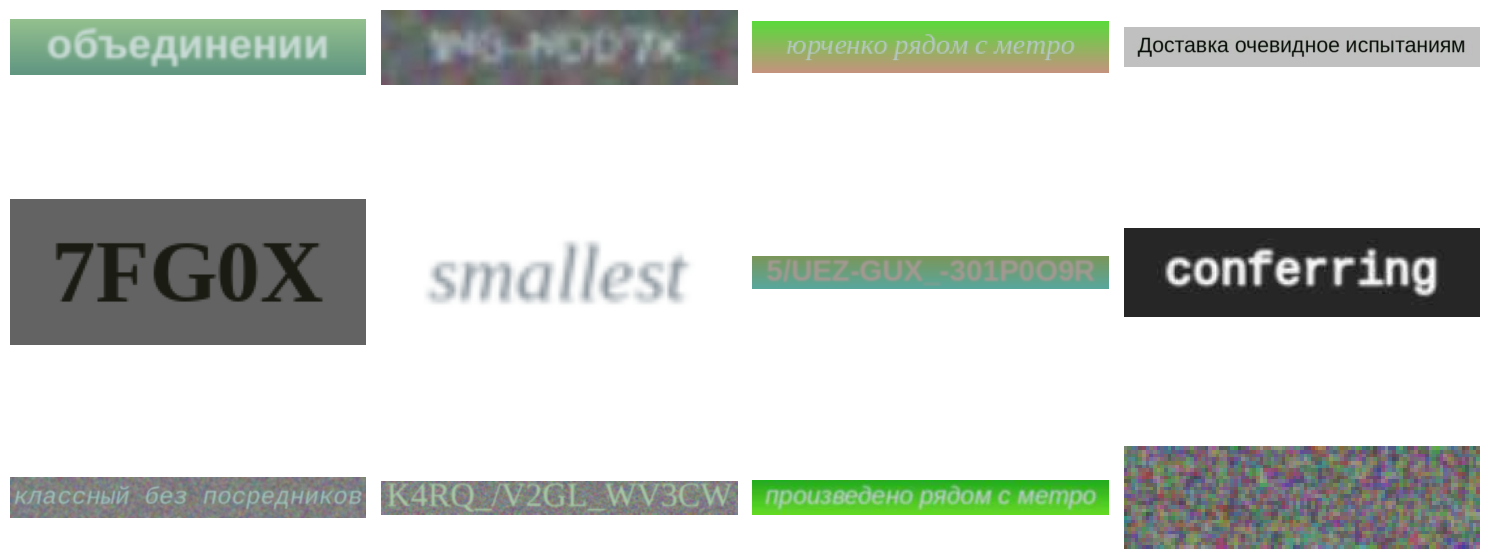

In [13]:
# ============================================================
# 2. SYNTHETIC TEXT
# ============================================================
from wordfreq import top_n_list
EN=[w for w in top_n_list("en",50000) if re.fullmatch(r"[A-Za-z0-9]+",w)]
RU=[w for w in top_n_list("ru",50000) if re.fullmatch(r"[А-Яа-яЁё0-9-]+",w)]
RU_T=["Продам {a}","Куплю {a}","Новый {a}","{a} в хорошем состоянии","{a} рядом с метро","Доставка {a}","Цена {a}","{a} без посредников"]
EN_T=["new {a}","for sale {a}","good condition {a}","{a} near city center","delivery available {a}","price for {a}","buy {a} today"]
fonts=[]
for root in ["/usr/share/fonts","/usr/local/share/fonts"]:
    if os.path.exists(root): fonts += [str(p) for p in Path(root).rglob("*.ttf")]
pref=[p for p in fonts if any(x in p.lower() for x in ["dejavu","noto","liberation","free"])]
fonts=pref+[p for p in fonts if p not in pref]
if not fonts: raise RuntimeError("No TTF fonts found")
ALNUM="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-_/"

def random_text():
    r=random.random()
    if r<.12: return "".join(random.choices(ALNUM,k=random.randint(4,22)))
    if r<.62:
        lang_ru=random.random()<.52
        pool=RU if lang_ru else EN
        template=random.choice(RU_T if lang_ru else EN_T)
        s=template.format(a=random.choice(pool))
        if random.random()<.30: s += " " + random.choice(RU if random.random()<.5 else EN)
        return s
    return random.choice(RU if random.random()<.48 else EN)

def jpeg(img,q):
    b=io.BytesIO(); img.save(b,format="JPEG",quality=q); b.seek(0); return Image.open(b).convert("RGB")

def add_noise(img,std):
    a=np.asarray(img).astype(np.float32)
    n=np.random.normal(0,std,a.shape).astype(np.float32)
    return Image.fromarray(np.uint8(np.clip(a+n,0,255)))

def synth_image():
    text=random_text()
    font=ImageFont.truetype(random.choice(fonts),random.randint(18,72))
    dummy=Image.new("RGB",(10,10)); d=ImageDraw.Draw(dummy)
    box=d.textbbox((0,0),text,font=font,stroke_width=random.choice([0,0,1]))
    tw,th=max(2,box[2]-box[0]),max(2,box[3]-box[1])
    px,py=random.randint(5,30),random.randint(4,20)
    bg_mode=random.random()
    if bg_mode<.45:
        bgv=random.randint(15,240); bg=(bgv,bgv,bgv)
        img=Image.new("RGB",(tw+2*px,th+2*py),bg)
    elif bg_mode<.75:
        c1=np.random.randint(20,235,3); c2=np.random.randint(20,235,3)
        h,w=th+2*py,tw+2*px
        yy=np.linspace(0,1,h)[:,None,None]
        arr=(c1[None,None,:]*(1-yy)+c2[None,None,:]*yy).repeat(w,axis=1)
        img=Image.fromarray(np.uint8(arr))
    else:
        arr=np.random.randint(20,236,(th+2*py,tw+2*px,3),dtype=np.uint8)
        img=Image.fromarray(arr).filter(ImageFilter.GaussianBlur(random.uniform(.5,2.0)))
    mean=np.asarray(img).mean()
    fgbase=random.randint(0,80) if mean>140 else random.randint(170,255)
    fg=tuple(max(0,min(255,fgbase+random.randint(-30,30))) for _ in range(3))
    ImageDraw.Draw(img).text((px-box[0],py-box[1]),text,font=font,fill=fg,stroke_width=random.choice([0,0,0,1]))
    if random.random()<.35: img=img.filter(ImageFilter.GaussianBlur(random.uniform(.1,1.4)))
    if random.random()<.55: img=ImageEnhance.Contrast(img).enhance(random.uniform(.5,1.5))
    if random.random()<.45: img=ImageEnhance.Brightness(img).enhance(random.uniform(.65,1.35))
    if random.random()<.35: img=add_noise(img,random.uniform(2,14))
    if random.random()<.35:
        ow,oh=img.size; f=random.uniform(.30,.85)
        sm=img.resize((max(8,int(ow*f)),max(8,int(oh*f))),Image.Resampling.BILINEAR)
        img=sm.resize((ow,oh),Image.Resampling.BILINEAR)
    if random.random()<.35: img=jpeg(img,random.randint(20,90))
    return img

fig,ax=plt.subplots(3,4,figsize=(15,8))
for a in ax.ravel(): a.imshow(synth_image()); a.axis("off")
plt.tight_layout(); plt.show()


In [14]:
# ============================================================
# 3. PREPROCESSING + DATASETS
# ============================================================
MEAN=(0.485,0.456,0.406); STD=(0.229,0.224,0.225)
class Letterbox:
    def __init__(self,size=(128,256),fill=(128,128,128)): self.h,self.w=size; self.fill=fill
    def __call__(self,img):
        img=img.convert("RGB"); ow,oh=img.size
        s=min(self.w/max(ow,1),self.h/max(oh,1))
        nw,nh=max(1,int(ow*s)),max(1,int(oh*s))
        img=img.resize((nw,nh),Image.Resampling.BICUBIC)
        out=Image.new("RGB",(self.w,self.h),self.fill); out.paste(img,((self.w-nw)//2,(self.h-nh)//2)); return out
train_tf=transforms.Compose([Letterbox((CFG["image_h"],CFG["image_w"])),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
val_tf=train_tf

class RealDS(Dataset):
    def __init__(self,paths,tf): self.paths=list(paths); self.tf=tf
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        img=Image.open(self.paths[i]).convert("RGB"); y=random.randint(0,1)
        if y: img=img.rotate(180,expand=True)
        return self.tf(img),torch.tensor(float(y)),self.paths[i]
class SynthDS(Dataset):
    def __init__(self,n,tf): self.n=int(n); self.tf=tf
    def __len__(self): return self.n
    def __getitem__(self,i):
        img=synth_image(); y=random.randint(0,1)
        if y: img=img.rotate(180,expand=True)
        return self.tf(img),torch.tensor(float(y)),f"synthetic_{i}"

def make_train_ds(paths,synthetic_fraction=CFG["synthetic_fraction"]):
    real=RealDS(paths,train_tf); n_syn=int(len(real)*synthetic_fraction/(1-synthetic_fraction))
    return ConcatDataset([real,SynthDS(n_syn,train_tf)])

class PairBaseDS(Dataset):
    """One base crop -> x0 and x180. Used for symmetry-aware inference."""
    def __init__(self,paths,tf): self.paths=list(paths); self.tf=tf
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        img=Image.open(self.paths[i]).convert("RGB")
        return self.tf(img),self.tf(img.rotate(180,expand=True)),self.paths[i]

def make_loader(ds,shuffle=False,batch=None):
    return DataLoader(ds,batch_size=batch or CFG["batch_size"],shuffle=shuffle,num_workers=CFG["num_workers"],pin_memory=torch.cuda.is_available(),persistent_workers=(CFG["num_workers"]>0))

def brier(y,p): return float(np.mean((np.asarray(p)-np.asarray(y))**2))
def metrics(y,p):
    y=np.asarray(y); p=np.asarray(p)
    return {"brier":brier(y,p),"1-brier":1-brier(y,p),"accuracy":accuracy_score(y,p>=.5),"roc_auc":roc_auc_score(y,p)}
def logit(p):
    p=np.clip(np.asarray(p),1e-6,1-1e-6); return np.log(p/(1-p))
def sigmoid(z): return 1/(1+np.exp(-np.asarray(z)))


## 3. EfficientNet training utilities

The important change is that every prediction used by the meta-model is generated by a model that **did not train on that crop**.


In [15]:
# ============================================================
# 4. EFFICIENTNET UTILITIES
# ============================================================
def build_effnet():
    m=efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier=nn.Sequential(nn.Dropout(CFG["dropout"]),nn.Linear(1280,1))
    return m.to(DEVICE)

def set_freeze(m,yes):
    for n,p in m.named_parameters(): p.requires_grad=(not yes) or n.startswith("classifier.")

def make_optimizer(m):
    return torch.optim.AdamW([
        {"params":[p for n,p in m.named_parameters() if p.requires_grad and not n.startswith("classifier.")],"lr":CFG["lr_backbone"]},
        {"params":[p for n,p in m.named_parameters() if p.requires_grad and n.startswith("classifier." )],"lr":CFG["lr_head"]},
    ],weight_decay=CFG["weight_decay"])

def train_effnet(paths,epochs,save_path=None):
    m=build_effnet(); set_freeze(m,True)
    opt=torch.optim.AdamW(filter(lambda p:p.requires_grad,m.parameters()),lr=CFG["lr_head"],weight_decay=CFG["weight_decay"])
    crit=nn.BCEWithLogitsLoss(); scaler=torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    loader=make_loader(make_train_ds(paths),shuffle=True)
    for epoch in range(epochs):
        if epoch==CFG["freeze_epochs"]:
            set_freeze(m,False); opt=make_optimizer(m)
        m.train(); total=n=0
        for x,y,_ in tqdm(loader,desc=f"train {epoch+1}/{epochs}",leave=False):
            x=x.to(DEVICE); y=y.to(DEVICE); opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()): loss=crit(m(x).squeeze(1),y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            total+=loss.item()*len(x); n+=len(x)
        print({"epoch":epoch+1,"loss":total/max(n,1)})
    if save_path: torch.save(m.state_dict(),save_path)
    return m

@torch.no_grad()
def eff_pair_logits(m,paths):
    loader=make_loader(PairBaseDS(paths,val_tf),shuffle=False)
    m.eval(); z0=[]; zr=[]
    for x,xr,_ in tqdm(loader,desc="EffNet pair",leave=False):
        x=x.to(DEVICE); xr=xr.to(DEVICE)
        z0.append(m(x).squeeze(1).float().cpu().numpy()); zr.append(m(xr).squeeze(1).float().cpu().numpy())
    return np.concatenate(z0),np.concatenate(zr)

def pair_to_examples(z0,zr):
    # For each base crop create both orientations, with balanced labels.
    margin=.5*(z0-zr)
    return np.concatenate([margin,-margin]), np.concatenate([np.zeros(len(margin)),np.ones(len(margin))])


## 4. PaddleOCR orientation expert

PaddleOCR documents `PP-LCNet_x1_0_textline_ori` as a two-class 0°/180° text-line orientation model. Its published model size is 6.5 MB. We use it only as a local model; no external inference API is involved.


In [17]:
!pip install paddlepaddle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


In [18]:
# ============================================================
# 5. PADDLE ORIENTATION
# ============================================================
USE_PADDLE=False; paddle_model=None
try:
    import paddle
    from paddleocr import TextLineOrientationClassification
    paddle_model=TextLineOrientationClassification(model_name=CFG["PADDLE_MODEL"],device="gpu" if torch.cuda.is_available() else "cpu")
    USE_PADDLE=bool(CFG["USE_PADDLE"])
    print("Paddle:",paddle.__version__,"enabled:",USE_PADDLE)
except Exception as e:
    print("Paddle orientation unavailable:",repr(e))
    print("The notebook can still run with EfficientNet + optional OCR disabled.")

def paddle_parse(res):
    d=res
    if hasattr(d,"json"):
        try:
            j=d.json; d=j() if callable(j) else j
            if isinstance(d,str): d=json.loads(d)
        except Exception: pass
    if isinstance(d,dict) and "res" in d: d=d["res"]
    def get(k,default=None): return d.get(k,default) if isinstance(d,dict) else getattr(d,k,default)
    label=get("label",get("label_names",None)); score=get("score",get("scores",None))
    if isinstance(label,(list,tuple,np.ndarray)): label=label[0]
    if isinstance(score,(list,tuple,np.ndarray)): score=score[0]
    s=str(label).lower() if label is not None else ""
    try: sc=float(score)
    except Exception: sc=.5
    return float(np.clip(sc if "180" in s else 1-sc,0,1))

def paddle_predict(paths,batch=32):
    if not USE_PADDLE: return np.full(len(paths),.5,dtype=np.float32)
    out=[]
    for i in tqdm(range(0,len(paths),batch),desc="Paddle orientation",leave=False):
        chunk=paths[i:i+batch]
        res=list(paddle_model.predict(chunk,batch_size=len(chunk)))
        if len(res)!=len(chunk): raise RuntimeError("Unexpected Paddle result count")
        out.extend(paddle_parse(r) for r in res)
    return np.asarray(out,dtype=np.float32)

def paddle_pair_prob(paths):
    p0=paddle_predict(paths);
    rot_dir=CACHE/"rot"; rot_dir.mkdir(exist_ok=True)
    rot=[]
    for i,p in enumerate(paths):
        q=rot_dir/f"{int(hashlib.sha1(str(p).encode()).hexdigest()[:12],16)}.jpg"
        if not q.exists(): Image.open(p).convert("RGB").rotate(180,expand=True).save(q,quality=95)
        rot.append(str(q))
    pr=paddle_predict(rot)
    # Antisymmetric probability: use logit difference, exactly as for EfficientNet.
    margin=.5*(logit(p0)-logit(pr))
    return sigmoid(margin),p0,pr


/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

The specified device (GPU) is not available! Switching to CPU instead.


Paddle: 3.3.1 enabled: True


## 5. Optional OCR recognition expert

Recognition is not the final OCR task. We only compare how confidently a local PaddleOCR recognizer reads the original crop versus its 180° rotation.

The adapter is deliberately defensive because PaddleOCR 3.x result objects have changed between minor releases. If recognition is unavailable, the rest of V3 remains runnable.


In [19]:
# ============================================================
# 6. PADDLE OCR RECOGNITION SIGNAL
# ============================================================
USE_OCR=False; rec_model=None
try:
    if USE_PADDLE and CFG["USE_OCR_RECOGNITION"]:
        from paddleocr import TextRecognition
        rec_model=TextRecognition(model_name=CFG["OCR_MODEL"],device="gpu" if torch.cuda.is_available() else "cpu")
        USE_OCR=True
        print("OCR recognition enabled:",CFG["OCR_MODEL"])
except Exception as e:
    print("OCR recognition unavailable:",repr(e))

def recursive_numbers(obj):
    vals=[]
    if isinstance(obj,(int,float,np.integer,np.floating)): vals.append(float(obj))
    elif isinstance(obj,dict):
        for k,v in obj.items():
            lk=str(k).lower()
            if any(t in lk for t in ["score","confidence","prob"]): vals += recursive_numbers(v)
            elif isinstance(v,(dict,list,tuple)): vals += recursive_numbers(v)
    elif isinstance(obj,(list,tuple)):
        for v in obj: vals += recursive_numbers(v)
    else:
        for k in ["score","scores","confidence","rec_score"]:
            if hasattr(obj,k): vals += recursive_numbers(getattr(obj,k))
    return vals

def rec_score(res):
    # Prefer explicit confidence/score fields. If unavailable, use 0.5.
    vals=recursive_numbers(res)
    vals=[v for v in vals if 0<=v<=1]
    return float(np.mean(vals)) if vals else .5

def recognition_predict(paths,batch=16):
    if not USE_OCR: return np.full(len(paths),.5,dtype=np.float32)
    out=[]
    for i in tqdm(range(0,len(paths),batch),desc="Paddle recognition",leave=False):
        chunk=paths[i:i+batch]
        try:
            res=list(rec_model.predict(input=chunk,batch_size=len(chunk)))
        except TypeError:
            res=list(rec_model.predict(chunk,batch_size=len(chunk)))
        if len(res)!=len(chunk): raise RuntimeError("Unexpected recognition result count")
        out.extend(rec_score(r) for r in res)
    return np.asarray(out,dtype=np.float32)

def recognition_pair_delta(paths):
    c0=recognition_predict(paths)
    rot_dir=CACHE/"rot_rec"; rot_dir.mkdir(exist_ok=True); rot=[]
    for i,p in enumerate(paths):
        q=rot_dir/f"{int(hashlib.sha1(str(p).encode()).hexdigest()[:12],16)}.jpg"
        if not q.exists(): Image.open(p).convert("RGB").rotate(180,expand=True).save(q,quality=95)
        rot.append(str(q))
    cr=recognition_predict(rot)
    return c0-cr,c0,cr


Using official model (PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_mobile_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

The specified device (GPU) is not available! Switching to CPU instead.


OCR recognition enabled: PP-OCRv5_mobile_rec


## 6. Cheap image/context features

These are deliberately weak features. They are context for calibration, not a shortcut for the label.


In [20]:
# ============================================================
# 7. IMAGE STATISTICS
# ============================================================
def image_features(paths):
    rows=[]
    for p in tqdm(paths,desc="image features",leave=False):
        im=Image.open(p).convert("L")
        a=np.asarray(im,dtype=np.float32)
        gy,gx=np.gradient(a)
        sharp=float(np.mean(gx*gx+gy*gy))
        rows.append([math.log(max(im.width,1)/max(im.height,1)),math.log(max(im.width*im.height,1)),float(a.mean()/255),float(a.std()/255),math.log1p(sharp)])
    return np.asarray(rows,dtype=np.float32)


## 7. OOF feature generation

For every fold:

- train EfficientNet only on the fold's training groups;
- predict the held-out groups in both orientations;
- run Paddle experts on the held-out groups;
- turn the pair into two balanced meta-examples (0° and 180°).

This is the key anti-leakage part of V3.


In [21]:
# ============================================================
# 8. OOF
# ============================================================
def make_meta_features(margin_eff, p_paddle, ocr_delta, stats, labels):
    # margin_eff and paddle probability are defined for canonical 0° orientation.
    # Build both labels so the meta model sees the exact symmetry expected at test time.
    n=len(labels)//2
    me=margin_eff[:n]
    pp=np.asarray(p_paddle[:n])
    od=np.asarray(ocr_delta[:n])
    st=np.asarray(stats[:n])
    # canonical features
    def block(sign):
        em=me*sign; pad=sigmoid(logit(pp)*sign); od_s=od*sign
        return np.column_stack([em,pad,logit(pad),od_s,abs(od_s),st])
    X=np.vstack([block(1),block(-1)])
    return X,np.asarray(labels)

all_train=np.asarray(train_paths)
skf=StratifiedKFold(n_splits=CFG["oof_folds"],shuffle=True,random_state=SEED)
# Stratify by coarse aspect-ratio bucket so every fold sees comparable geometry.
ratios=[]
for p in all_train:
    try:
        with Image.open(p) as im: r=im.width/max(im.height,1)
    except: r=1
    ratios.append(0 if r<.75 else 1 if r<1.5 else 2 if r<3 else 3)
ratios=np.asarray(ratios)

if CFG["RUN_OOF"]:
    oof_X=[]; oof_y=[]; fold_scores=[]
    for fold,(tr,va) in enumerate(skf.split(all_train,ratios),1):
        print("\n========== FOLD",fold,"/",CFG["oof_folds"],"==========")
        tr_paths=all_train[tr].tolist(); va_paths=all_train[va].tolist()
        model=train_effnet(tr_paths,CFG["oof_epochs"],CKPT/f"effnet_oof_{fold}.pt")
        z0,zr=eff_pair_logits(model,va_paths)
        margin=.5*(z0-zr)
        ppad,_,_=paddle_pair_prob(va_paths) if USE_PADDLE else (np.full(len(va_paths),.5),None,None)
        ocrd,_,_=recognition_pair_delta(va_paths) if USE_OCR else (np.zeros(len(va_paths),dtype=np.float32),None,None)
        st=image_features(va_paths)
        # two balanced orientations
        X=np.vstack([
            np.column_stack([margin,ppad,logit(ppad),ocrd,np.abs(ocrd),st]),
            np.column_stack([-margin,1-ppad,-logit(ppad),-ocrd,np.abs(ocrd),st]),
        ])
        yy=np.concatenate([np.zeros(len(va_paths)),np.ones(len(va_paths))])
        # Base EfficientNet-only score for diagnostics.
        p_eff=sigmoid(np.concatenate([margin,-margin]))
        print("fold EffNet:",metrics(yy,p_eff))
        oof_X.append(X); oof_y.append(yy)
        del model; gc.collect();
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    X_oof=np.vstack(oof_X); y_oof=np.concatenate(oof_y)
    np.savez_compressed(CACHE/"oof_features.npz",X=X_oof,y=y_oof)
    print("OOF shape:",X_oof.shape)
else:
    d=np.load(CACHE/"oof_features.npz"); X_oof=d["X"]; y_oof=d["y"]
    print("Loaded OOF:",X_oof.shape)



========== FOLD 1 / 5 ==========
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]
/tmp/ipykernel_984/1497841397.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  crit=nn.BCEWithLogitsLoss(); scaler=torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


train 1/4:   0%|          | 0/112 [00:00<?, ?it/s]

/tmp/ipykernel_984/1497841397.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()): loss=crit(m(x).squeeze(1),y)


{'epoch': 1, 'loss': 0.7028071642206987}


...

Paddle orientation:   0%|          | 0/25 [00:00<?, ?it/s]

Paddle recognition:   0%|          | 0/50 [00:00<?, ?it/s]

Paddle recognition:   0%|          | 0/50 [00:00<?, ?it/s]

image features:   0%|          | 0/800 [00:00<?, ?it/s]

fold EffNet: {'brier': 0.08313754483549579, '1-brier': 0.9168624551645042, 'accuracy': 0.885, 'roc_auc': 0.958921875}
OOF shape: (8000, 10)


## 8. Meta-model and Brier calibration

The meta-model is intentionally tiny. It sees independent expert signals and disagreement, then learns a probability rather than a hard class.


In [22]:
# ============================================================
# 9. META MODEL + CALIBRATION
# ============================================================
meta=LogisticRegression(C=0.5,max_iter=2000,random_state=SEED)
meta.fit(X_oof,y_oof)
p_meta=meta.predict_proba(X_oof)[:,1]
print("OOF meta:",metrics(y_oof,p_meta))

# Brier-optimized Platt calibration on OOF predictions.
# We search a small 2-parameter family without touching test labels.
z_meta=logit(p_meta)
best=(1e9,1.0,0.0)
for T in np.exp(np.linspace(np.log(.25),np.log(4),161)):
    for b in np.linspace(-0.35,0.35,71):
        p=sigmoid(z_meta/T+b); br=brier(y_oof,p)
        if br<best[0]: best=(br,float(T),float(b))
best_brier,best_T,best_b=best
p_oof_cal=sigmoid(z_meta/best_T+best_b)
print({"T":best_T,"bias":best_b,"OOF calibrated":metrics(y_oof,p_oof_cal)})

# Also report simpler experts for comparison.
print("Meta coefficients:")
feature_names=["eff_margin","paddle_p","paddle_logit","ocr_delta","ocr_abs_delta","log_aspect","log_area","brightness","contrast","log_sharpness"]
print(pd.DataFrame({"feature":feature_names,"coef":meta.coef_[0]}))


OOF meta: {'brier': 0.010482339881102374, '1-brier': 0.9895176601188976, 'accuracy': 0.985625, 'roc_auc': 0.9992205}
{'T': 0.9170040432046712, 'bias': 5.551115123125783e-17, 'OOF calibrated': {'brier': 0.010459614840091645, '1-brier': 0.9895403851599084, 'accuracy': 0.985625, 'roc_auc': 0.9992205}}
Meta coefficients:
         feature      coef
0     eff_margin  0.746541
1       paddle_p -0.174379
2   paddle_logit  0.752088
3      ocr_delta -5.694871
4  ocr_abs_delta -0.022397
5     log_aspect -0.012265
6       log_area  0.004049
7     brightness -0.000261
8       contrast  0.000892
9  log_sharpness  0.009034


## 9. Full-train EfficientNet and final test features

After OOF/meta training, fit one EfficientNet on all available real training groups plus the synthetic stream. This model is used only for final test inference.


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
!rm -rf /content/testimgs

In [27]:
!unzip "/content/drive/MyDrive/images.zip" -d "/content/testimgs"

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/testimgs/images/test_15000.png  
  inflating: /content/testimgs/images/test_15001.png  
  inflating: /content/testimgs/images/test_15002.png  
  inflating: /content/testimgs/images/test_15003.png  
  inflating: /content/testimgs/images/test_15004.png  
  inflating: /content/testimgs/images/test_15005.png  
  inflating: /content/testimgs/images/test_15006.png  
  inflating: /content/testimgs/images/test_15007.png  
  inflating: /content/testimgs/images/test_15008.png  
  inflating: /content/testimgs/images/test_15009.png  
  inflating: /content/testimgs/images/test_15010.png  
  inflating: /content/testimgs/images/test_15011.png  
  inflating: /content/testimgs/images/test_15012.png  
  inflating: /content/testimgs/images/test_15013.png  
  inflating: /content/testimgs/images/test_15014.png  
  inflating: /content/testimgs/images/test_15015.png  
  inflating: /content/testimgs/images/test_15016.png

In [31]:
# ============================================================
# 10. FINAL EFFICIENTNET
# ============================================================
final_model_path=CKPT/"effnet_v3_final.pt"
if final_model_path.exists():
    final_eff=build_effnet(); final_eff.load_state_dict(torch.load(final_model_path,map_location=DEVICE)); print("Loaded final checkpoint")
else:
    final_eff=train_effnet(all_train.tolist(),CFG["final_epochs"],final_model_path)


Loaded final checkpoint


In [32]:
# ============================================================
# 11. TEST INFERENCE + SUBMISSION
# ============================================================

@torch.no_grad()
def eff_test_margin(paths):
    paths = [str(p) for p in paths]

    z0, zr = eff_pair_logits(final_eff, paths)

    # Positive margin = original orientation is more likely
    return 0.5 * (z0 - zr)


def build_test_X(paths):
    paths = [str(p) for p in paths]

    # --------------------------------------------------------
    # 1. EfficientNet orientation signal
    # --------------------------------------------------------
    em = eff_test_margin(paths)

    # --------------------------------------------------------
    # 2. PaddleOCR orientation signal
    # --------------------------------------------------------
    if USE_PADDLE:
        pp, _, _ = paddle_pair_prob(paths)
    else:
        pp = np.full(len(paths), 0.5, dtype=np.float32)

    # --------------------------------------------------------
    # 3. OCR recognition signal
    # --------------------------------------------------------
    if USE_OCR:
        ocrd, _, _ = recognition_pair_delta(paths)
    else:
        ocrd = np.zeros(len(paths), dtype=np.float32)

    # --------------------------------------------------------
    # 4. Image statistics
    # --------------------------------------------------------
    stats = image_features(paths)

    # --------------------------------------------------------
    # IMPORTANT:
    # Feature order MUST be identical to the one used during OOF.
    #
    # OOF:
    # [margin, paddle_p, paddle_logit,
    #  ocr_delta, abs(ocr_delta), image_stats...]
    # --------------------------------------------------------
    X = np.column_stack([
        em,
        pp,
        logit(pp),
        ocrd,
        np.abs(ocrd),
        stats,
    ]).astype(np.float32)

    return X


def make_submission(TEST_DIR, OUT):
    """
    Create submission.csv directly from test images.

    No sample_submission.csv is required.

    Required output:
        image_id,p_180

    image_id:
        filename without extension

    p_180:
        probability in [0, 1]
    """

    TEST_DIR = Path(TEST_DIR)
    OUT = Path(OUT)

    if not TEST_DIR.exists():
        raise FileNotFoundError(
            f"Test directory does not exist: {TEST_DIR}"
        )

    # --------------------------------------------------------
    # Find test images
    # --------------------------------------------------------
    image_exts = {
        ".jpg",
        ".jpeg",
        ".png",
        ".webp",
        ".bmp",
    }

    image_paths = sorted([
        p
        for p in TEST_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in image_exts
    ])

    if len(image_paths) == 0:
        raise RuntimeError(
            f"No images found in {TEST_DIR}"
        )

    print(f"Found {len(image_paths):,} test images")

    # --------------------------------------------------------
    # image_id
    #
    # If the competition expects filename WITH extension,
    # replace p.stem with p.name.
    # --------------------------------------------------------
    image_ids = [
        p.stem
        for p in image_paths
    ]

    # --------------------------------------------------------
    # Convert Path -> str before inference
    # --------------------------------------------------------
    paths = [
        str(p)
        for p in image_paths
    ]

    # --------------------------------------------------------
    # Build model features
    # --------------------------------------------------------
    X_test = build_test_X(paths)

    print("Test feature matrix:", X_test.shape)

    # --------------------------------------------------------
    # Meta-model prediction
    # --------------------------------------------------------
    p_180 = meta.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Brier calibration learned ONLY on OOF
    # --------------------------------------------------------
    p_180 = sigmoid(
        logit(p_180) / best_T + best_b
    )

    # Safety clipping
    p_180 = np.clip(
        p_180,
        0.0,
        1.0
    )

    # --------------------------------------------------------
    # Create submission from scratch
    # --------------------------------------------------------
    sub = pd.DataFrame({
        "image_id": image_ids,
        "p_180": p_180.astype(np.float64),
    })

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    assert list(sub.columns) == [
        "image_id",
        "p_180"
    ]

    assert len(sub) == len(image_paths)

    assert sub["image_id"].notna().all()

    assert sub["image_id"].is_unique

    assert np.isfinite(
        sub["p_180"].to_numpy()
    ).all()

    assert (
        (sub["p_180"] >= 0.0) &
        (sub["p_180"] <= 1.0)
    ).all()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    OUT.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    sub.to_csv(
        OUT,
        index=False
    )

    print()
    print("=" * 60)
    print("SUBMISSION CREATED")
    print("=" * 60)
    print(f"File:   {OUT}")
    print(f"Rows:   {len(sub):,}")
    print(f"Columns: {list(sub.columns)}")
    print(
        f"p_180:  "
        f"min={sub.p_180.min():.6f}, "
        f"max={sub.p_180.max():.6f}, "
        f"mean={sub.p_180.mean():.6f}"
    )
    print("=" * 60)

    display(sub.head())
    display(sub.tail())

    return sub

In [ ]:
submission = make_submission(
    TEST_DIR="/content/testimgs/images",
    OUT=ROOT / "submission_v3.csv",
)

## 10. Recommended final checks before submission

1. Compare OOF Brier of EfficientNet-only, Paddle-only, meta-model and calibrated meta-model.
2. Inspect `meta.coef_`: if one expert gets a near-zero coefficient, it is not helping.
3. Verify `submission_v3.csv` has exactly `image_id,p_180`, 20 000 rows and probabilities in `[0,1]`.
4. Record the exact configuration and leaderboard score.
5. Do not hand-edit test predictions.

### External/open-source components used

- ImageNet-pretrained torchvision EfficientNet-B0.
- IIIT5K as the real public training source.
- PaddleOCR `PP-LCNet_x1_0_textline_ori` for text-line orientation.
- Optional PaddleOCR PP-OCRv5 recognition model for the recognition-confidence signal.

PaddleOCR's current documentation describes `PP-LCNet_x1_0_textline_ori` as a 0°/180° classifier and provides the Python `TextLineOrientationClassification` API.
